In [1]:
import os
import random
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
def accuracy_from_logits(logits, y_true):
    return (torch.argmax(logits, dim=1) == y_true).float().mean().item()

def plot_history(history, title=""):
    epochs = range(1, len(history["train_loss"])+1)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train", marker="o")
    plt.plot(epochs, history["val_loss"], label="val", marker="s")
    plt.title("Loss")
    plt.legend()
    plt.grid()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="train", marker="o")
    plt.plot(epochs, history["val_acc"], label="val", marker="s")
    plt.title("Accuracy")
    plt.legend()
    plt.grid()
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [4]:
print("LOADING DATA")

DATASET_NAME = "EMNIST"

if DATASET_NAME == "KMNIST":
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    train_full = torchvision.datasets.KMNIST(root="./data", train=True, download=True, transform=transform)
    test_ds = torchvision.datasets.KMNIST(root="./data", train=False, download=True, transform=transform)
    INPUT_DIM = 28 * 28
    NUM_CLASSES = 10
    
elif DATASET_NAME == "EMNIST":
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    train_full = torchvision.datasets.EMNIST(root="./data", split="balanced", train=True, download=True, transform=transform)
    test_ds = torchvision.datasets.EMNIST(root="./data", split="balanced", train=False, download=True, transform=transform)
    INPUT_DIM = 28 * 28
    NUM_CLASSES = 47
    
elif DATASET_NAME == "CIFAR10":
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    train_full = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
    test_ds = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
    INPUT_DIM = 32 * 32 * 3
    NUM_CLASSES = 10

print(f"Dataset: {DATASET_NAME}")
print(f"Classes: {NUM_CLASSES}, Train: {len(train_full)}, Test: {len(test_ds)}")

LOADING DATA
Dataset: EMNIST
Classes: 47, Train: 112800, Test: 18800


In [5]:
BATCH_SIZE = 256 if device.type == "cuda" else 64
NUM_WORKERS = 0 if os.name == "nt" else 2

val_size = int(len(train_full) * 0.2)
train_ds, val_ds = random_split(train_full, [len(train_full) - val_size, val_size], 
                                 generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=device.type=="cuda")
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=device.type=="cuda")
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=device.type=="cuda")

x_batch, y_batch = next(iter(train_loader))
print(f"Batch shape: x={x_batch.shape}, y={y_batch.shape}")
print(f"x range: [{x_batch.min():.3f}, {x_batch.max():.3f}]")

Batch shape: x=torch.Size([256, 1, 28, 28]), y=torch.Size([256])
x range: [-1.000, 1.000]


In [6]:
class MLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=(256, 128), num_classes=10, dropout_p=0.0, use_batchnorm=False):
        super().__init__()
        layers = [nn.Flatten()]
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout_p > 0:
                layers.append(nn.Dropout(dropout_p))
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

In [7]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    loss_sum, acc_sum, n = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
        acc_sum += accuracy_from_logits(logits, y)
        n += 1
    return loss_sum / n, acc_sum / n

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, acc_sum, n = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        loss_sum += loss.item()
        acc_sum += accuracy_from_logits(logits, y)
        n += 1
    return loss_sum / n, acc_sum / n

In [8]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.best = None
        self.state = None
        self.cnt = 0
    
    def step(self, score, model):
        if self.best is None or score > self.best:
            self.best = score
            self.state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.cnt = 0
            return False
        self.cnt += 1
        return self.cnt >= self.patience
    
    def restore(self, model):
        if self.state:
            model.load_state_dict(self.state)
            print("  Best weights restored")

In [9]:
def fit(model, train_loader, val_loader, optimizer, criterion, device, epochs=20, early_stopping=None, verbose=True):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for ep in range(1, epochs + 1):
        tl, ta = train_epoch(model, train_loader, optimizer, criterion, device)
        vl, va = evaluate(model, val_loader, criterion, device)
        history["train_loss"].append(tl)
        history["train_acc"].append(ta)
        history["val_loss"].append(vl)
        history["val_acc"].append(va)
        if verbose:
            print(f"  Ep {ep:02d} | train: {tl:.4f}/{ta:.4f} | val: {vl:.4f}/{va:.4f}")
        if early_stopping and early_stopping.step(va, model):
            print(f"  Early Stopping @ epoch {ep}")
            early_stopping.restore(model)
            break
    return history

In [10]:
LR_BASE = 1e-3
EPOCHS_BASE = 20
EPOCHS_ES = 50
HIDDEN_DIMS = (256, 128)
DROPOUT_P = 0.3
criterion = nn.CrossEntropyLoss()

os.makedirs("artifacts/figures", exist_ok=True)
print("Folders ready")

Folders ready


E1: Base MLP
  Ep 01 | train: 1.4921/0.5836 | val: 1.0143/0.7013
  Ep 02 | train: 0.8485/0.7422 | val: 0.7517/0.7722
  Ep 03 | train: 0.6730/0.7881 | val: 0.6735/0.7902
  Ep 04 | train: 0.5842/0.8115 | val: 0.6016/0.8092
  Ep 05 | train: 0.5305/0.8267 | val: 0.5822/0.8079
  Ep 06 | train: 0.4922/0.8358 | val: 0.5516/0.8220
  Ep 07 | train: 0.4636/0.8420 | val: 0.5354/0.8268
  Ep 08 | train: 0.4402/0.8485 | val: 0.5196/0.8310
  Ep 09 | train: 0.4185/0.8548 | val: 0.5152/0.8305
  Ep 10 | train: 0.4039/0.8574 | val: 0.5108/0.8341
  Ep 11 | train: 0.3849/0.8638 | val: 0.5111/0.8357
  Ep 12 | train: 0.3748/0.8659 | val: 0.5105/0.8329
  Ep 13 | train: 0.3607/0.8706 | val: 0.5107/0.8380
  Ep 14 | train: 0.3444/0.8748 | val: 0.5082/0.8391
  Ep 15 | train: 0.3357/0.8775 | val: 0.5086/0.8356
  Ep 16 | train: 0.3267/0.8801 | val: 0.5296/0.8321
  Ep 17 | train: 0.3152/0.8829 | val: 0.5173/0.8345
  Ep 18 | train: 0.3082/0.8851 | val: 0.5164/0.8429
  Ep 19 | train: 0.2979/0.8879 | val: 0.5181/0.8385

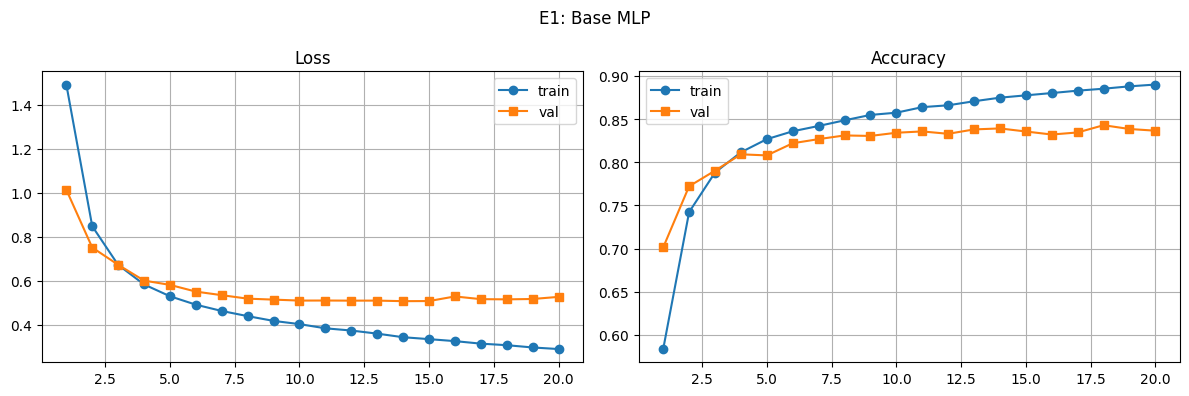

E2: MLP + Dropout
  Ep 01 | train: 1.8300/0.4818 | val: 1.0221/0.6971
  Ep 02 | train: 1.1427/0.6559 | val: 0.8108/0.7537
  Ep 03 | train: 0.9902/0.6959 | val: 0.7155/0.7757
  Ep 04 | train: 0.9030/0.7192 | val: 0.6679/0.7896
  Ep 05 | train: 0.8528/0.7332 | val: 0.6313/0.7999
  Ep 06 | train: 0.8160/0.7436 | val: 0.6128/0.8022
  Ep 07 | train: 0.7918/0.7477 | val: 0.5914/0.8103
  Ep 08 | train: 0.7708/0.7534 | val: 0.5747/0.8134
  Ep 09 | train: 0.7529/0.7581 | val: 0.5724/0.8132
  Ep 10 | train: 0.7376/0.7612 | val: 0.5610/0.8170
  Ep 11 | train: 0.7229/0.7668 | val: 0.5502/0.8202
  Ep 12 | train: 0.7138/0.7675 | val: 0.5494/0.8196
  Ep 13 | train: 0.6970/0.7728 | val: 0.5363/0.8240
  Ep 14 | train: 0.6958/0.7731 | val: 0.5269/0.8278
  Ep 15 | train: 0.6859/0.7752 | val: 0.5249/0.8257
  Ep 16 | train: 0.6765/0.7780 | val: 0.5236/0.8284
  Ep 17 | train: 0.6710/0.7781 | val: 0.5155/0.8300
  Ep 18 | train: 0.6716/0.7783 | val: 0.5148/0.8305
  Ep 19 | train: 0.6629/0.7817 | val: 0.5194/0

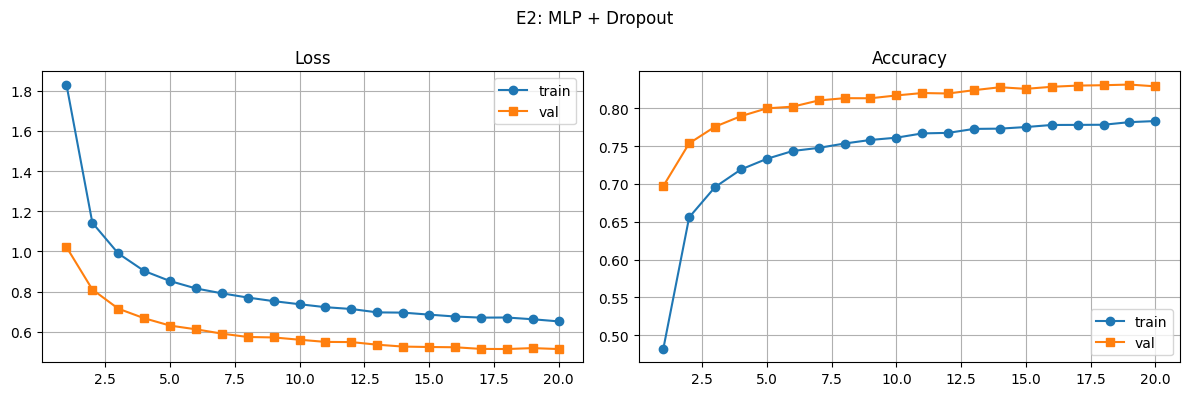

E3: MLP + BatchNorm
  Ep 01 | train: 1.1464/0.7082 | val: 0.6655/0.7943
  Ep 02 | train: 0.5505/0.8235 | val: 0.5476/0.8205
  Ep 03 | train: 0.4534/0.8473 | val: 0.5047/0.8344
  Ep 04 | train: 0.4020/0.8617 | val: 0.4858/0.8378
  Ep 05 | train: 0.3665/0.8710 | val: 0.4971/0.8327
  Ep 06 | train: 0.3367/0.8796 | val: 0.4748/0.8431
  Ep 07 | train: 0.3160/0.8847 | val: 0.4689/0.8466
  Ep 08 | train: 0.2943/0.8916 | val: 0.4836/0.8416
  Ep 09 | train: 0.2794/0.8963 | val: 0.4768/0.8449
  Ep 10 | train: 0.2632/0.9013 | val: 0.4851/0.8455
  Ep 11 | train: 0.2524/0.9043 | val: 0.4890/0.8443
  Ep 12 | train: 0.2381/0.9082 | val: 0.5011/0.8410
  Ep 13 | train: 0.2264/0.9123 | val: 0.5097/0.8430
  Ep 14 | train: 0.2181/0.9164 | val: 0.5151/0.8428
  Ep 15 | train: 0.2089/0.9179 | val: 0.5194/0.8406
  Ep 16 | train: 0.2004/0.9221 | val: 0.5287/0.8406
  Ep 17 | train: 0.1926/0.9241 | val: 0.5434/0.8385
  Ep 18 | train: 0.1866/0.9257 | val: 0.5545/0.8381
  Ep 19 | train: 0.1806/0.9290 | val: 0.5562

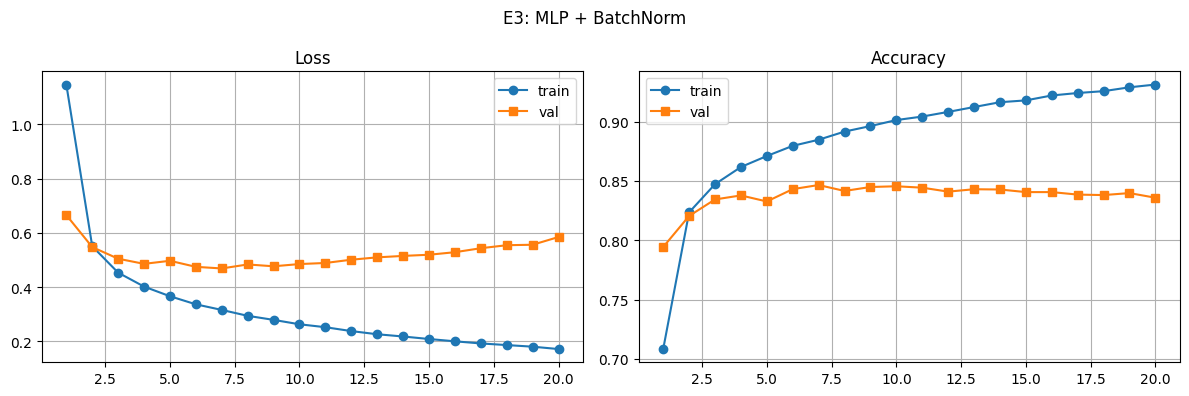

E4: EarlyStopping
E2 best val_acc: 0.8314
E3 best val_acc: 0.8466
Choosing E3 (BatchNorm) architecture
  Ep 01 | train: 1.1464/0.7082 | val: 0.6655/0.7943
  Ep 02 | train: 0.5505/0.8235 | val: 0.5476/0.8205
  Ep 03 | train: 0.4534/0.8473 | val: 0.5047/0.8344
  Ep 04 | train: 0.4020/0.8617 | val: 0.4858/0.8378
  Ep 05 | train: 0.3665/0.8710 | val: 0.4971/0.8327
  Ep 06 | train: 0.3367/0.8796 | val: 0.4748/0.8431
  Ep 07 | train: 0.3160/0.8847 | val: 0.4689/0.8466
  Ep 08 | train: 0.2943/0.8916 | val: 0.4836/0.8416
  Ep 09 | train: 0.2794/0.8963 | val: 0.4768/0.8449
  Ep 10 | train: 0.2632/0.9013 | val: 0.4851/0.8455
  Ep 11 | train: 0.2524/0.9043 | val: 0.4890/0.8443
  Ep 12 | train: 0.2381/0.9082 | val: 0.5011/0.8410
  Early Stopping @ epoch 12
  Best weights restored


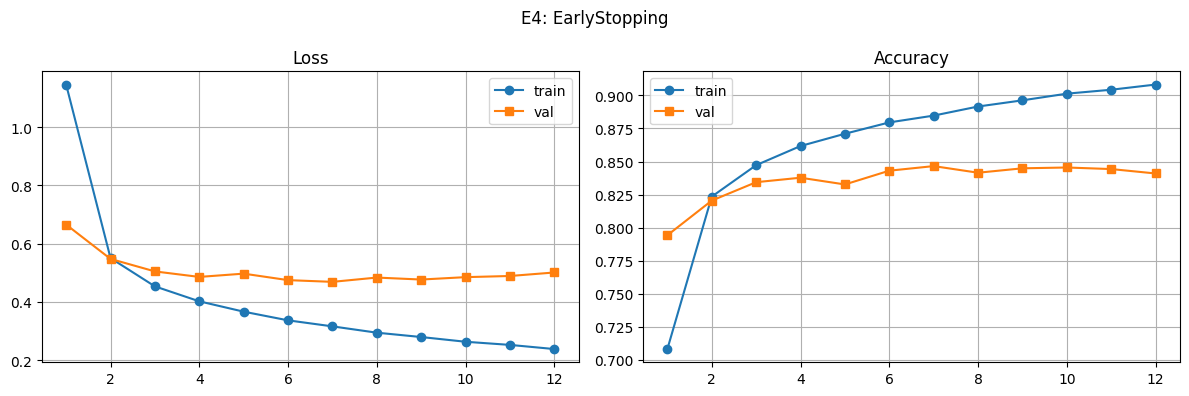

O1: LR too high (Adam lr=1e-1)
  Ep 01 | train: 1.0465/0.6828 | val: 0.8040/0.7438
  Ep 02 | train: 0.6993/0.7726 | val: 0.6914/0.7806
  Ep 03 | train: 0.6243/0.7927 | val: 0.6747/0.7850
  Ep 04 | train: 0.5740/0.8081 | val: 0.6276/0.7999
  Ep 05 | train: 0.5481/0.8131 | val: 0.6603/0.7914
  Ep 06 | train: 0.5249/0.8220 | val: 0.6386/0.8043
  Ep 07 | train: 0.5031/0.8267 | val: 0.5758/0.8160
  Ep 08 | train: 0.4869/0.8307 | val: 0.5703/0.8200


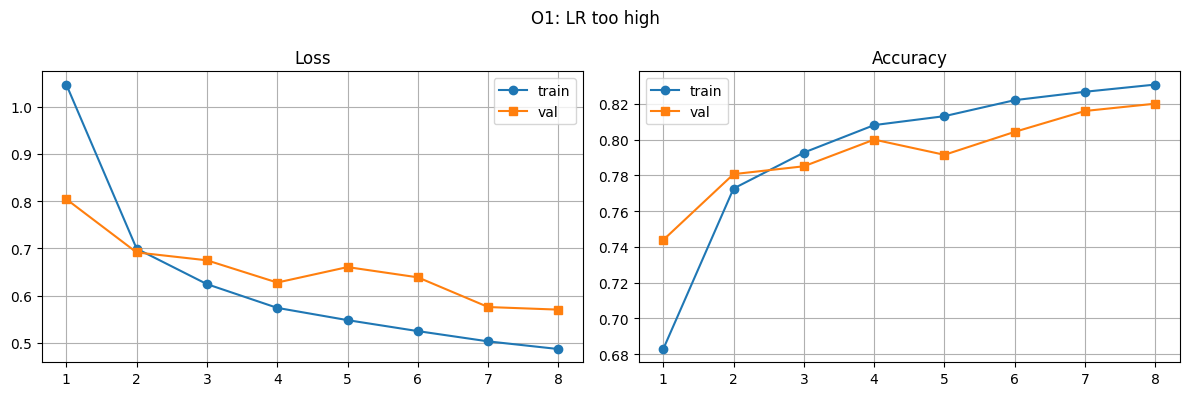

O2: LR too low (Adam lr=1e-5)
  Ep 01 | train: 3.6213/0.1066 | val: 3.3495/0.2077
  Ep 02 | train: 3.1615/0.2973 | val: 2.9956/0.3681
  Ep 03 | train: 2.8730/0.4206 | val: 2.7582/0.4601
  Ep 04 | train: 2.6628/0.4904 | val: 2.5701/0.5154
  Ep 05 | train: 2.4917/0.5363 | val: 2.4128/0.5550
  Ep 06 | train: 2.3440/0.5693 | val: 2.2783/0.5834
  Ep 07 | train: 2.2137/0.5933 | val: 2.1597/0.6054
  Ep 08 | train: 2.0952/0.6145 | val: 2.0463/0.6226


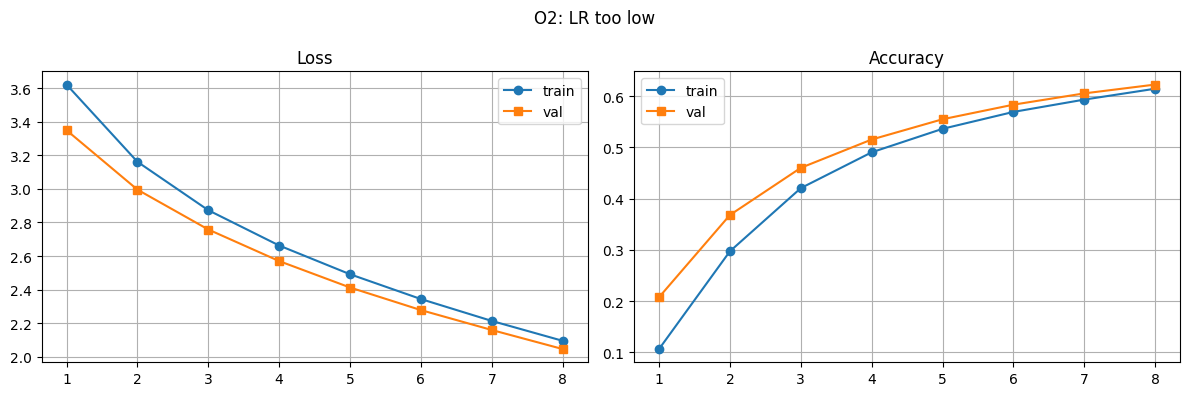

O3: SGD+momentum + weight_decay
  Ep 01 | train: 1.4191/0.6498 | val: 0.7740/0.7747
  Ep 02 | train: 0.6545/0.7999 | val: 0.6106/0.8069
  Ep 03 | train: 0.5291/0.8300 | val: 0.5431/0.8287
  Ep 04 | train: 0.4659/0.8460 | val: 0.5191/0.8320
  Ep 05 | train: 0.4239/0.8584 | val: 0.5045/0.8314
  Ep 06 | train: 0.3950/0.8658 | val: 0.4856/0.8402
  Ep 07 | train: 0.3702/0.8725 | val: 0.4714/0.8440
  Ep 08 | train: 0.3491/0.8784 | val: 0.4761/0.8439
  Ep 09 | train: 0.3309/0.8829 | val: 0.4726/0.8430
  Ep 10 | train: 0.3157/0.8881 | val: 0.4698/0.8436
  Ep 11 | train: 0.3034/0.8907 | val: 0.4683/0.8461
  Ep 12 | train: 0.2904/0.8952 | val: 0.4810/0.8407
  Ep 13 | train: 0.2787/0.8990 | val: 0.4796/0.8438
  Ep 14 | train: 0.2684/0.9030 | val: 0.4808/0.8418
  Ep 15 | train: 0.2611/0.9034 | val: 0.4855/0.8392


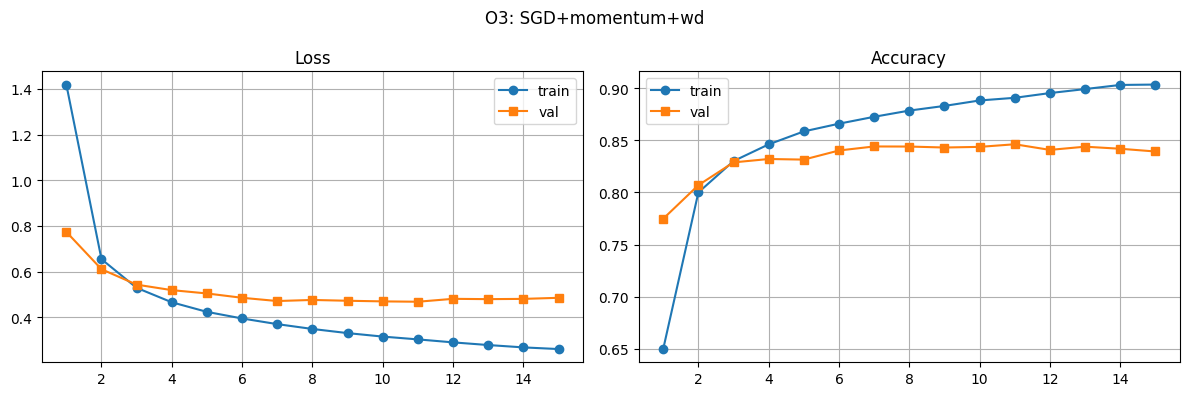

In [11]:
print("E1: Base MLP")
set_seed(SEED)
m1 = MLP(input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS, num_classes=NUM_CLASSES, dropout_p=0.0, use_batchnorm=False).to(device)
h1 = fit(m1, train_loader, val_loader, optim.Adam(m1.parameters(), lr=LR_BASE), criterion, device, EPOCHS_BASE)
plot_history(h1, "E1: Base MLP")

print("E2: MLP + Dropout")
set_seed(SEED)
m2 = MLP(input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS, num_classes=NUM_CLASSES, dropout_p=DROPOUT_P, use_batchnorm=False).to(device)
h2 = fit(m2, train_loader, val_loader, optim.Adam(m2.parameters(), lr=LR_BASE), criterion, device, EPOCHS_BASE)
plot_history(h2, "E2: MLP + Dropout")

print("E3: MLP + BatchNorm")
set_seed(SEED)
m3 = MLP(input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS, num_classes=NUM_CLASSES, dropout_p=0.0, use_batchnorm=True).to(device)
h3 = fit(m3, train_loader, val_loader, optim.Adam(m3.parameters(), lr=LR_BASE), criterion, device, EPOCHS_BASE)
plot_history(h3, "E3: MLP + BatchNorm")

print("E4: EarlyStopping")
best_val_e2 = max(h2["val_acc"])
best_val_e3 = max(h3["val_acc"])
print(f"E2 best val_acc: {best_val_e2:.4f}")
print(f"E3 best val_acc: {best_val_e3:.4f}")

if best_val_e2 >= best_val_e3:
    print("Choosing E2 (Dropout) architecture")
    use_dropout, use_bn = DROPOUT_P, False
    model_summary = f"MLP+Dropout({DROPOUT_P})+EarlyStopping"
else:
    print("Choosing E3 (BatchNorm) architecture")
    use_dropout, use_bn = 0.0, True
    model_summary = "MLP+BatchNorm+EarlyStopping"

set_seed(SEED)
m4 = MLP(input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS, num_classes=NUM_CLASSES, dropout_p=use_dropout, use_batchnorm=use_bn).to(device)
es = EarlyStopping(patience=5)
h4 = fit(m4, train_loader, val_loader, optim.Adam(m4.parameters(), lr=LR_BASE), criterion, device, EPOCHS_ES, es)
plot_history(h4, "E4: EarlyStopping")

print("O1: LR too high (Adam lr=1e-1)")
set_seed(SEED)
m_o1 = MLP(input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS, num_classes=NUM_CLASSES, dropout_p=use_dropout, use_batchnorm=use_bn).to(device)
h_o1 = fit(m_o1, train_loader, val_loader, optim.Adam(m_o1.parameters(), lr=1e-1), criterion, device, 8)
plot_history(h_o1, "O1: LR too high")

print("O2: LR too low (Adam lr=1e-5)")
set_seed(SEED)
m_o2 = MLP(input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS, num_classes=NUM_CLASSES, dropout_p=use_dropout, use_batchnorm=use_bn).to(device)
h_o2 = fit(m_o2, train_loader, val_loader, optim.Adam(m_o2.parameters(), lr=1e-5), criterion, device, 8)
plot_history(h_o2, "O2: LR too low")

print("O3: SGD+momentum + weight_decay")
set_seed(SEED)
m_o3 = MLP(input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS, num_classes=NUM_CLASSES, dropout_p=use_dropout, use_batchnorm=use_bn).to(device)
h_o3 = fit(m_o3, train_loader, val_loader, 
           optim.SGD(m_o3.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4), 
           criterion, device, 15)
plot_history(h_o3, "O3: SGD+momentum+wd")

In [12]:
results = [
    {"experiment_id": "E1", "dataset": DATASET_NAME, "seed": SEED,
     "model_summary": f"MLP({INPUT_DIM}→256→128→{NUM_CLASSES})",
     "optimizer": "Adam", "lr": LR_BASE, "momentum": 0, "weight_decay": 0,
     "epochs_trained": len(h1["val_acc"]),
     "best_val_accuracy": max(h1["val_acc"]), "best_val_loss": min(h1["val_loss"])},
    
    {"experiment_id": "E2", "dataset": DATASET_NAME, "seed": SEED,
     "model_summary": f"MLP+Dropout({DROPOUT_P})",
     "optimizer": "Adam", "lr": LR_BASE, "momentum": 0, "weight_decay": 0,
     "epochs_trained": len(h2["val_acc"]),
     "best_val_accuracy": max(h2["val_acc"]), "best_val_loss": min(h2["val_loss"])},
    
    {"experiment_id": "E3", "dataset": DATASET_NAME, "seed": SEED,
     "model_summary": "MLP+BatchNorm",
     "optimizer": "Adam", "lr": LR_BASE, "momentum": 0, "weight_decay": 0,
     "epochs_trained": len(h3["val_acc"]),
     "best_val_accuracy": max(h3["val_acc"]), "best_val_loss": min(h3["val_loss"])},
    
    {"experiment_id": "E4", "dataset": DATASET_NAME, "seed": SEED,
     "model_summary": model_summary,
     "optimizer": "Adam", "lr": LR_BASE, "momentum": 0, "weight_decay": 0,
     "epochs_trained": len(h4["val_acc"]),
     "best_val_accuracy": max(h4["val_acc"]), "best_val_loss": min(h4["val_loss"])},
    
    {"experiment_id": "O1", "dataset": DATASET_NAME, "seed": SEED,
     "model_summary": model_summary,
     "optimizer": "Adam", "lr": 1e-1, "momentum": 0, "weight_decay": 0,
     "epochs_trained": len(h_o1["val_acc"]),
     "best_val_accuracy": max(h_o1["val_acc"]), "best_val_loss": min(h_o1["val_loss"])},
    
    {"experiment_id": "O2", "dataset": DATASET_NAME, "seed": SEED,
     "model_summary": model_summary,
     "optimizer": "Adam", "lr": 1e-5, "momentum": 0, "weight_decay": 0,
     "epochs_trained": len(h_o2["val_acc"]),
     "best_val_accuracy": max(h_o2["val_acc"]), "best_val_loss": min(h_o2["val_loss"])},
    
    {"experiment_id": "O3", "dataset": DATASET_NAME, "seed": SEED,
     "model_summary": model_summary,
     "optimizer": "SGD", "lr": 1e-2, "momentum": 0.9, "weight_decay": 1e-4,
     "epochs_trained": len(h_o3["val_acc"]),
     "best_val_accuracy": max(h_o3["val_acc"]), "best_val_loss": min(h_o3["val_loss"])}
]

df_results = pd.DataFrame(results)
df_results.to_csv("artifacts/runs.csv", index=False)
print("Saved: artifacts/runs.csv")
print(df_results[["experiment_id", "best_val_accuracy", "best_val_loss"]])

Saved: artifacts/runs.csv
  experiment_id  best_val_accuracy  best_val_loss
0            E1           0.842872       0.508151
1            E2           0.831373       0.514678
2            E3           0.846559       0.468883
3            E4           0.846559       0.468883
4            O1           0.820049       0.570314
5            O2           0.622630       2.046292
6            O3           0.846120       0.468285


In [13]:
torch.save(m4.state_dict(), "artifacts/best_model.pt")
print("Saved: artifacts/best_model.pt")

# Получим test accuracy для сохранения в конфиг
test_loss, test_acc = evaluate(m4, test_loader, criterion, device)

config = {
    "experiment_id": "E4",
    "dataset": DATASET_NAME,
    "seed": SEED,
    "architecture": {
        "input_dim": INPUT_DIM,
        "hidden_dims": list(HIDDEN_DIMS),
        "num_classes": NUM_CLASSES,
        "dropout_p": use_dropout,
        "use_batchnorm": use_bn,
        "activation": "ReLU"
    },
    "training": {
        "optimizer": "Adam",
        "lr": LR_BASE,
        "weight_decay": 0,
        "momentum": 0,
        "batch_size": BATCH_SIZE,
        "loss_function": "CrossEntropyLoss",
        "val_split": 0.2,
        "early_stopping_patience": 5,
        "max_epochs": EPOCHS_ES
    },
    "results": {
        "best_val_accuracy": float(max(h4["val_acc"])),
        "best_val_loss": float(min(h4["val_loss"])),
        "epochs_trained": len(h4["val_acc"]),
        "test_accuracy": float(test_acc)
    }
}
with open("artifacts/best_config.json", "w") as f:
    json.dump(config, f, indent=2)
print("Saved: artifacts/best_config.json")

Saved: artifacts/best_model.pt
Saved: artifacts/best_config.json


In [14]:
epochs = range(1, len(h4["train_loss"]) + 1)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, h4["train_loss"], label="train", marker="o")
plt.plot(epochs, h4["val_loss"], label="val", marker="s")
plt.title("Loss")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(epochs, h4["train_acc"], label="train", marker="o")
plt.plot(epochs, h4["val_acc"], label="val", marker="s")
plt.title("Accuracy")
plt.legend()
plt.grid()

plt.suptitle(f"E4: Best Model (val_acc={max(h4['val_acc']):.4f})")
plt.tight_layout()
plt.savefig("artifacts/figures/curves_best.png", dpi=300, bbox_inches="tight")
plt.close()
print("Saved: artifacts/figures/curves_best.png")

Saved: artifacts/figures/curves_best.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_o1 = range(1, len(h_o1["train_loss"]) + 1)
axes[0].plot(epochs_o1, h_o1["train_loss"], label="train", marker="o")
axes[0].plot(epochs_o1, h_o1["val_loss"], label="val", marker="s")
axes[0].set_title(f"O1: LR too high (1e-1)\nval_acc={max(h_o1['val_acc']):.4f}")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid()

epochs_o2 = range(1, len(h_o2["train_loss"]) + 1)
axes[1].plot(epochs_o2, h_o2["train_loss"], label="train", marker="o")
axes[1].plot(epochs_o2, h_o2["val_loss"], label="val", marker="s")
axes[1].set_title(f"O2: LR too low (1e-5)\nval_acc={max(h_o2['val_acc']):.4f}")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid()

plt.suptitle("LR Diagnostics: Too High vs Too Low", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("artifacts/figures/curves_lr_extremes.png", dpi=300, bbox_inches="tight")
plt.close()
print("Saved: artifacts/figures/curves_lr_extremes.png")

Saved: artifacts/figures/curves_lr_extremes.png


In [16]:
print("FINAL TEST EVALUATION (E4)")
test_loss, test_acc = evaluate(m4, test_loader, criterion, device)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

print("HW08-09 COMPLETED!")
print(f"Best model: E4")
print(f"Best val_acc: {max(h4['val_acc']):.4f}")
print(f"Test acc: {test_acc:.4f}")

FINAL TEST EVALUATION (E4)
Test Accuracy: 0.8416
Test Loss: 0.4819
HW08-09 COMPLETED!
Best model: E4
Best val_acc: 0.8466
Test acc: 0.8416
